# This code is updated to 03/08/2026 date
All written down from here is already in english

### 1. All librarys are called
---
All the usual stats libs are called, pandas for dataframe, numpy for maths, matplotlib for simple prots, stats models for IVF, and sklearn for data processing. 

The library altair is called to save more complex graphs like correlation graph.

The line `%pip install --upgrade pyarrow` line is stated to ensure the lastest version of pyarrow to be installed, this is because of multiple errors showed due the size of the data loaded in the graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import altair as alt
alt.data_transformers.enable("vegafusion")
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%pip install --upgrade pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Data preprocessing 
---
In this part of the code all the data from the data base is reviwed and fixed.

### 3.  Data variable labels are translated
---
The datased is downloaded from an Spanish Speaking Country service (INEN) all the labels are in spanish and in order to publish this reasearch in an international journal all the the labels must be in English, thats why in the next code block we did what we did

In [ ]:
df = pd.read_csv(
    'data/indicadores_mensuales.csv',
    encoding='latin1',
    sep=';',
    decimal=','
)

# Traducir nombres de columnas al inglés
translation_dict = {
    'anio': 'year',
    'periodo': 'period',
    'mes': 'month',
    'area': 'area',
    'ciudad': 'city',
    'tasa_participacion_global': 'global_participation_rate',
    'tasa_participacion_bruta': 'gross_participation_rate',
    'tasa_desempleo': 'unemployment_rate',
    'empleo_total': 'total_employment',
    'empleo_formal': 'formal_employment',
    'empleo_informal': 'informal_employment',
    'empleo_adecuado': 'adequate_employment',
    'subempleo': 'underemployment',
    'no_remunerado': 'unpaid_work',
    'otro_no_pleno': 'other_non_full_employment',
    'brecha_adecuado_HM': 'adequate_employment_gap_hm',
    'brecha_salarial_HM': 'salary_gap_hm',
    'NiNi': 'neet',
    'desempleo_juvenil': 'youth_unemployment',
    'trabajo_infantil': 'child_labor',
    'empleo_manufactura': 'manufacturing_employment',
    'tasa_asistencia_clases': 'school_attendance_rate',
    'pobreza_ingresos': 'income_poverty',
    'pobreza_extrema_ingresos': 'extreme_income_poverty'
}

# Renombrar columnas que existan
for old_name, new_name in translation_dict.items():
    if old_name in df.columns:
        df = df.rename(columns={old_name: new_name})

df.columns = df.columns.str.lower()


although some columns data are "numbers" they are actually tags (strings), in the next block we ensure to change the data type of the columns city, month, and print `.head()` and `.info()` to show dataframe info

In [3]:

if 'city' in df.columns:
    df['city'] = df['city'].astype('Int64').astype(str).str.zfill(6)

id_str_cols = ['city', 'month']
id_int_cols = ['year', 'period', 'area']
for col in df.columns:
    if col not in id_str_cols and col not in id_int_cols:
        df[col] = df[col].astype('Float64')
    if col in id_int_cols:
        df[col] = df[col].astype('Int64')

In [4]:
df.head()

,year,period,month,area,city,global_participation_rate,gross_participation_rate,unemployment_rate,total_employment,formal_employment,...,other_non_full_employment,adequate_employment_gap_hm,salary_gap_hm,neet,youth_unemployment,child_labor,manufacturing_employment,school_attendance_rate,income_poverty,extreme_income_poverty
0,2007,6,Junio,1,010150,69.6709,50.6597,5.6692,94.3308,67.7679,...,14.9143,32.5062,38.3322,8.8601,8.4198,5.0324,19.5232,79.0481,12.9154,3.4991
1,2007,6,Junio,1,070150,69.5793,47.9878,6.39,93.61,44.5163,...,18.088,24.5242,19.8952,18.1669,8.9962,4.7061,8.7018,73.8733,23.7168,7.3746
2,2007,6,Junio,1,090150,70.2874,50.1103,8.9783,91.0217,53.3911,...,15.6068,32.5023,28.153,17.665,15.9064,6.1991,13.7591,75.6331,19.1637,6.132
3,2007,6,Junio,1,170150,68.7131,50.6626,5.9597,94.0403,68.125,...,14.0037,32.6926,47.4736,11.6609,9.6217,4.873,14.9477,77.9396,11.7764,3.4935
4,2007,6,Junio,1,180150,67.9143,50.2609,4.2956,95.7044,68.6879,...,16.9191,33.5418,32.4586,9.4014,8.6598,5.4683,18.4217,81.4531,14.2329,4.2952


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        835 non-null    Int64  
 1   period                      835 non-null    Int64  
 2   month                       835 non-null    str    
 3   area                        835 non-null    Int64  
 4   city                        835 non-null    str    
 5   global_participation_rate   835 non-null    Float64
 6   gross_participation_rate    835 non-null    Float64
 7   unemployment_rate           835 non-null    Float64
 8   total_employment            835 non-null    Float64
 9   formal_employment           835 non-null    Float64
 10  informal_employment         835 non-null    Float64
 11  adequate_employment         835 non-null    Float64
 12  underemployment             835 non-null    Float64
 13  unpaid_work                 835 non-null    Fl

Since some columns are just labels in the next block we create an "id" array for the number columns names called "num_cols" to over `df[num_cols]` use `.describe()` to see the general statistics for the dataframe

In [6]:
id_cols = ['year','period','month','area', 'city']
num_cols = [c for c in df.columns if c not in id_cols]
df[num_cols].describe()

,global_participation_rate,gross_participation_rate,unemployment_rate,total_employment,formal_employment,informal_employment,adequate_employment,underemployment,unpaid_work,other_non_full_employment,adequate_employment_gap_hm,salary_gap_hm,neet,youth_unemployment,child_labor,manufacturing_employment,school_attendance_rate,income_poverty,extreme_income_poverty
count,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,835.0,828.0,831.0,828.0,824.0,827.0,835.0,834.0,835.0,835.0
mean,66.421,49.749414,5.140647,94.859353,60.185546,32.689166,48.424601,16.87754,5.574277,23.395945,29.677616,22.437376,16.677933,10.678949,2.053821,13.906131,77.996113,12.788551,3.596361
std,7.342329,6.954126,3.774066,3.774066,15.766562,14.825057,13.165283,9.512025,4.200056,9.736476,43.426929,23.886686,12.092971,9.726943,6.823578,7.326927,9.443054,10.594457,5.010565
min,38.4615,21.2766,0.0,69.2308,0.0,0.0,0.0,0.0,0.0,0.0,-641.1434,-197.0297,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,62.5,46.3561,3.1732,93.1122,51.8337,22.33785,42.14425,10.0,3.2581,17.8999,20.995425,15.48975,10.4446,6.0178,0.0,9.65825,75.193925,7.355,0.8039
50%,65.2478,48.8146,4.6611,95.3389,63.3186,28.9503,49.4147,15.7148,4.7665,21.4286,27.9088,22.6154,15.7354,9.66995,0.4858,14.2857,79.5962,10.9077,2.4604
75%,69.3602,51.86475,6.8878,96.8268,71.7984,39.96175,57.09925,21.822,7.17925,25.8383,36.469375,30.18175,20.361575,13.8404,1.85515,18.39135,82.60005,16.4557,4.06515
max,100.0,86.6667,30.7692,100.0,100.0,100.0,100.0,66.6667,26.6205,76.9231,100.0,100.0,100.0,100.0,100.0,39.5074,100.0,91.0714,50.0


### 4. Now we do an exploratory data analysis
---
Since i want to do histograms and see how the data for each column behavies we have to "melt" the dataframe in a 2 columns times MxN data array, where M is the name of different columns and N number of values for each column. That's why i used `.melt()`, as shown in the next block   

In [7]:
df_long = df[num_cols].melt(var_name='variable', value_name='value')
df_long['variable'] = df_long['variable'].astype('category')

As now i have this two column (variable, value) i can do an histogram analysis.
The general histogram graph is saved "graphs" folder inside this repository.

In [8]:
variables = df_long['variable'].unique()
charts = []
for var in variables:
    df_sub = df_long[df_long['variable'] == var]
    chart = alt.Chart(df_sub, title=var).mark_bar().encode(
        x=alt.X(
            'value:Q', 
            bin=alt.Bin(maxbins=30), 
            title='Porcentaje (%)',
            axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
        ),
        y=alt.Y('count():Q', title='Frecuencia')
    ).properties(
        width=180, 
        height=120
    )
    
    charts.append(chart)

chart_hist = alt.concat(*charts, columns=4).properties(
    title='Distribuciones por variable'
)

chart_hist.save("graphs/chart_histogram.png")
chart_hist.show()

alt.ConcatChart(...)

In the same fashion as i did before i did a boxplot analysis, which graph is also saved in "graphs" folder

In [21]:
variables = df_long['variable'].unique()
charts_boxplot = []

for var in variables:
    df_sub = df_long[df_long['variable'] == var]
    chart = alt.Chart(df_sub).mark_boxplot().encode(
        x=alt.X(
        'value:Q',
        #scale=alt.Scale(domain=[0, 100]),
        title=None,
        axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
        ),
        y=alt.Y(
        'variable:N',title=None
        )
    ).properties(
    width=350,
    height=40,
    )
    
    charts_boxplot.append(chart)

charts_boxplot = alt.concat(*charts_boxplot, columns=2).properties(
    title='Boxplots per variable'
)

charts_boxplot.save("graphs/boxplot.png")

### 5. Pearson Correlation
---
In order to know how correlated are each pair of different variables, we use `.corr(method='pearson')` over the dataframe df

In [10]:
corr = df[num_cols].corr(method='pearson')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
)

corr_pairs.columns = ['variable_1', 'variable_2', 'pearson_r']
corr_pairs['abs_r'] = corr_pairs['pearson_r'].abs()

corr_pairs = corr_pairs.sort_values('abs_r', ascending=False).reset_index(drop=True)

corr_pairs.head(30)

,variable_1,variable_2,pearson_r,abs_r
0,unemployment_rate,total_employment,-1.000000,1.000000
1,formal_employment,informal_employment,-0.894791,0.894791
2,global_participation_rate,gross_participation_rate,0.824314,0.824314
3,unemployment_rate,youth_unemployment,0.783137,0.783137
4,total_employment,youth_unemployment,-0.783137,0.783137
5,income_poverty,extreme_income_poverty,0.663085,0.663085
6,adequate_employment,underemployment,-0.625282,0.625282
7,formal_employment,adequate_employment,0.619133,0.619133
8,informal_employment,adequate_employment,-0.606817,0.606817
9,adequate_employment,other_non_full_employment,-0.591012,0.591012


Now i draw the correalation matrix and,  as the other graphs, it's saved in "graphs" folder 

In [11]:
corr = df[num_cols].corr(method='pearson')

corr_long = (
    corr.reset_index()
    .melt(id_vars='index', var_name='variable_2', value_name='correlacion')
    .rename(columns={'index': 'variable_1'})
)

orden_vars = corr.columns.tolist()
idx_map = {var: i for i, var in enumerate(orden_vars)}

corr_long['i'] = corr_long['variable_1'].map(idx_map)
corr_long['j'] = corr_long['variable_2'].map(idx_map)

# solo triángulo inferior
corr_long_inf = corr_long[corr_long['i'] < corr_long['j']]

base = alt.Chart(corr_long_inf).encode(
    x=alt.X('variable_1:N', sort=orden_vars, title=None),
    y=alt.Y('variable_2:N', sort=orden_vars, title=None),
    tooltip=[
        alt.Tooltip('variable_1:N', title='Variable 1'),
        alt.Tooltip('variable_2:N', title='Variable 2'),
        alt.Tooltip('correlacion:Q', format='.3f', title='Correlación')
    ]
)

heatmap = base.mark_rect().encode(
    color=alt.Color(
        'correlacion:Q',
        scale=alt.Scale(
            domain=[-1, 0, 1],
            range=['#b2182b', '#f7f7f7', '#2166ac']
        ),
        title='r de Pearson'
    )
)

text = base.mark_text(fontSize=10).encode(
    text=alt.Text('correlacion:Q', format='.2f'),
    color=alt.condition(
        'abs(datum.correlacion) >= 0.5',
        alt.value('white'),
        alt.value('black')
    )
)

chart = (heatmap + text).properties(
    width=600,
    height=600,
    title='Matriz de correlación de Pearson'
).configure_view(
    strokeWidth=0
)

chart.save("graficas/boxplot.png")

### 6. Variance Inflation Factor
---
As i want to know which variable contributes more to the standard error in the regression. 

In [12]:
X = df[num_cols]
X = X.apply(pd.to_numeric, errors='coerce').dropna()

X_const = sm.add_constant(X)

X_const = X_const.astype(float)

vif_df = pd.DataFrame({
    'variable': X_const.columns,
    'VIF': [
        variance_inflation_factor(X_const.to_numpy(dtype=float), i)
        for i in range(X_const.shape[1])
    ]
})

# remove the intercept from the VIF table
vif_df = vif_df[vif_df['variable'] != 'const'].reset_index(drop=True)

vif_df['tolerancia'] = 1 / vif_df['VIF']
vif_df

c:\Users\wwwis\OneDrive\Desktop\repositorio_prueba\monica\Para_Jugar\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\wwwis\OneDrive\Desktop\repositorio_prueba\monica\Para_Jugar\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF,tolerancia
0,global_participation_rate,4.367084,0.228986
1,gross_participation_rate,5.740292,0.174207
2,unemployment_rate,inf,0.000000
3,total_employment,inf,0.000000
4,formal_employment,6.193080,0.161471
5,informal_employment,5.579149,0.179239
6,adequate_employment,112.407280,0.008896
7,underemployment,61.837276,0.016171
8,unpaid_work,12.999292,0.076927
9,other_non_full_employment,58.895170,0.016979


### 7. Principal Component Analysis 
--- 
Now i'm gonna do PCA to reduce the dimensionality of the dataset to only two components that will be called PC1 and PC2. In order to apply PCA over the data the dataframe must be fitted and applied the dimensionality reduction. 

first, i erease the ``total_employment`` column due it high colineality with `unemployment_rate` and create a new dataframe `X` for which all the empty values are dropped.

Then i call a ``scaler `` variable to scale the dataframe values into a new scaled dataframe `X_scaled`. 

Then a variable with the structure of the pca dataframe is called, and then over this pca structured dataframe is applied the `.fit_transform` to contain ``X_scaled`` values. This new dataframe is called `X_pca`  


In [13]:
new_id_cols = id_cols.copy()
new_id_cols.append('total_employment')
X = df.drop(columns=new_id_cols).copy()
X = X.apply(pd.to_numeric, errors='coerce').dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA() # dataframe with pca allowed structure
X_pca = pca.fit_transform(X_scaled) #X_scaled transformed into PCA structure

Now we define a function to do all the hard work for every dataframe with PCA allowed structure

In [14]:
def plot_pca_biplot(pca, X_pca, X_scaled, feature_names, pc_x=0, pc_y=1,
                   scale_factor=3, figsize=(12, 9)):
    """
    Biplot: scatter of observations on PCs + loading vectors.

    Parameters
    ----------
    pca          : fitted PCA object
    X_pca        : transformed data (n_samples, n_components)
    X_scaled     : standardized original data (for coloring by density, optional)
    feature_names: list of original variable names
    pc_x, pc_y   : which PCs to plot (0-indexed)
    scale_factor : multiplier to stretch loading arrows for visibility
    """
    fig, ax = plt.subplots(figsize=figsize)

    # ── 1. Scatter of observations ────────────────────────────────────────────
    ax.scatter(X_pca[:, pc_x], X_pca[:, pc_y],
               alpha=0.35, s=18, color='steelblue', label='Observations')

    # ── 2. Loading vectors ────────────────────────────────────────────────────
    loadings = pca.components_  # shape: (n_components, n_features)

    for i, feature in enumerate(feature_names):
        vx = loadings[pc_x, i] * scale_factor
        vy = loadings[pc_y, i] * scale_factor

        ax.annotate(
            '', xy=(vx, vy), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8)
        )
        ax.text(vx * 1.08, vy * 1.08, feature,
                fontsize=8, color='crimson', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

    # ── 3. Axis labels with explained variance ───────────────────────────────
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC{pc_x+1}  ({var[pc_x]*100:.1f}% var)', fontsize=12)
    ax.set_ylabel(f'PC{pc_y+1}  ({var[pc_y]*100:.1f}% var)', fontsize=12)
    ax.set_title('PCA Biplot — Observations & Loading Vectors', fontsize=14, fontweight='bold')

    # ── 4. Reference lines & legend ──────────────────────────────────────────
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.axvline(0, color='grey', lw=0.7, ls='--')

    obs_patch   = mpatches.Patch(color='steelblue', label='Observations')
    arrow_patch = mpatches.Patch(color='crimson',   label='Loading vectors')
    ax.legend(handles=[obs_patch, arrow_patch], loc='lower right')

    plt.tight_layout()
    plt.savefig('graphs/pca_biplot.png', dpi=150)

Finally PCA over `X_pca` with the feature names in `feature_names` a graph for PCA is generated  

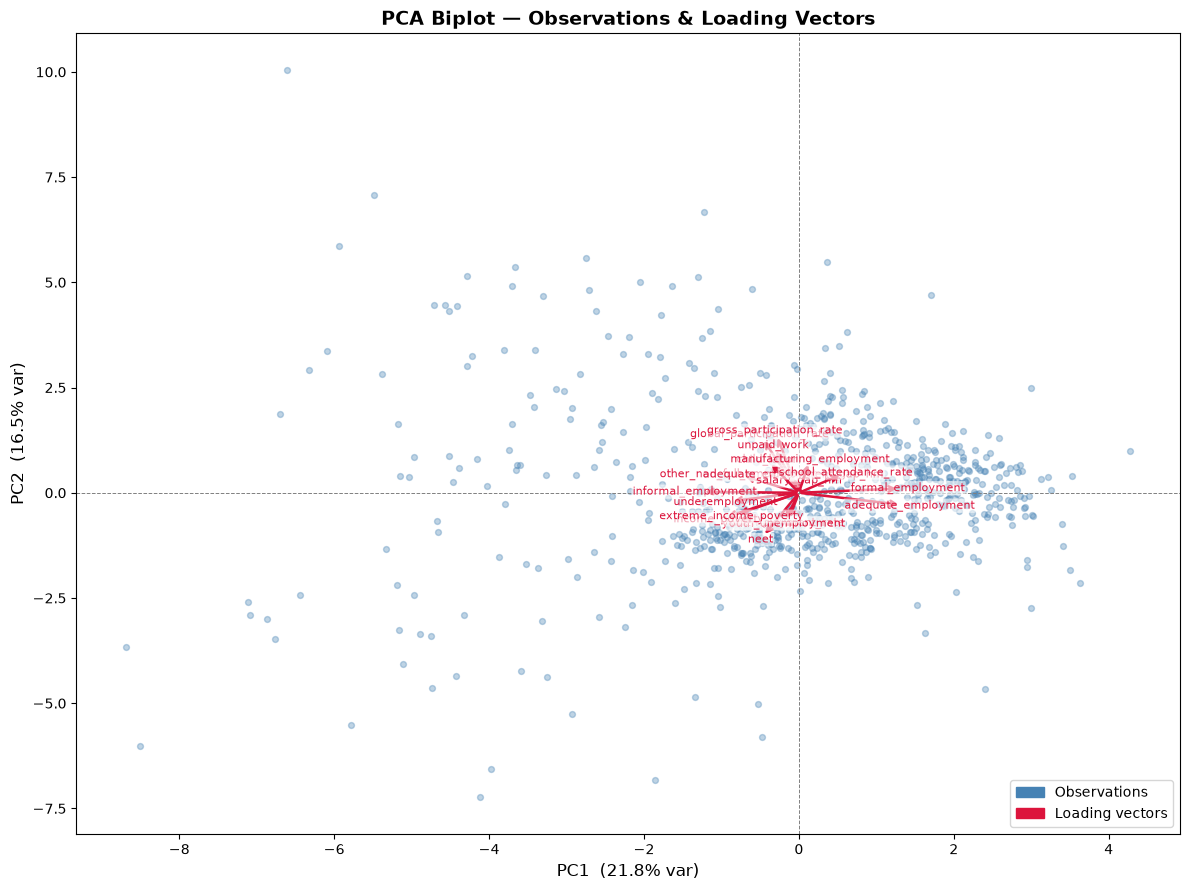

In [15]:
feature_names = [c for c in df.columns if c not in new_id_cols]

plot_pca_biplot(pca, X_pca, X_scaled, feature_names,
                pc_x=0, pc_y=1,   # change to explore other component pairs
                scale_factor=3)

### 8. Variance and Weights of principal components
---


In [16]:
explained_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'explained_variance': pca.explained_variance_ratio_,
    'aggregate_variance': pca.explained_variance_ratio_.cumsum()
})

explained_variance

,Component,explained_variance,aggregate_variance
0,PC1,0.217809,0.217809
1,PC2,0.165427,0.383236
2,PC3,0.107491,0.490726
3,PC4,0.088067,0.578793
4,PC5,0.080842,0.659635
5,PC6,0.055976,0.715611
6,PC7,0.052621,0.768233
7,PC8,0.049192,0.817425
8,PC9,0.041638,0.859062
9,PC10,0.034896,0.893958


#### 8.1 PC1 & PC2 Weights
---

In [17]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2], 
    columns=['PC1', 'PC2'],
    index=X.columns
)

# This is all you need to see the final result:
loadings.sort_values(by='PC1', ascending=False)

,PC1,PC2
adequate_employment,0.440732,-0.094790
formal_employment,0.433308,0.033690
school_attendance_rate,0.186998,0.148392
manufacturing_employment,0.043844,0.245541
salary_gap_hm,0.001207,0.090349
adequate_employment_gap_hm,-0.022429,0.133597
unemployment_rate,-0.045392,-0.221243
youth_unemployment,-0.061928,-0.225982
gross_participation_rate,-0.095929,0.455262
unpaid_work,-0.103466,0.348275


### 9.  Multivariate Composite Index
---

 - 0 = peor ICM relativo observado
 - 100 = mejor ICM relativo observado

In [18]:
indice_compuesto_multivariado = X_pca[:, 0]

indice_df = df.loc[X.index, id_cols].copy()
indice_df['indice_compuesto_multivariado'] = indice_compuesto_multivariado

indice_min = indice_df['indice_compuesto_multivariado'].min()
indice_max = indice_df['indice_compuesto_multivariado'].max()

# Transformación min-max del indice
indice_df['indice_compuesto_multivariado_0_100'] = (
    (indice_df['indice_compuesto_multivariado'] - indice_min) / (indice_max - indice_min)
) * 100

indice_df

,year,period,month,area,city,indice_compuesto_multivariado,indice_compuesto_multivariado_0_100
0,2007,6,Junio,1,010150,1.197765,76.263097
1,2007,6,Junio,1,070150,-1.950585,51.959910
2,2007,6,Junio,1,090150,-0.771270,61.063448
3,2007,6,Junio,1,170150,1.199826,76.279002
4,2007,6,Junio,1,180150,0.977625,74.563756
...,...,...,...,...,...,...,...
830,2026,4,Abril,1,070150,-0.229175,65.248063
831,2026,4,Abril,1,090150,-0.304468,64.666849
832,2026,4,Abril,1,170150,1.941992,82.008032
833,2026,4,Abril,1,180150,0.023609,67.199389


### 10. Time series of the MCI
---

Since i want to see how each variable evolve over the time the most conviniento way to do it is trough time series of the MCI. In order to do it we have to change the format of the data time providen by the dataset. The following code block do that

In [19]:
Unique_cities = len(df['city'].unique())

# sort first
indice_df = indice_df.sort_values(['city', 'year', 'month']).copy()

#then the date format is applied
indice_df['date'] = pd.to_datetime(df['year'].astype(str) + '/' + df['period'].astype(str), format='%Y/%m')

indice_df.head()

,year,period,month,area,city,indice_compuesto_multivariado,indice_compuesto_multivariado_0_100,date
10,2007,12,Diciembre,1,010150,1.822126,81.082752,2007-12-01
0,2007,6,Junio,1,010150,1.197765,76.263097,2007-06-01
5,2007,9,Septiembre,1,010150,1.321938,77.221627,2007-09-01
37,2008,12,Diciembre,1,010150,2.276687,84.591663,2008-12-01
24,2008,6,Junio,1,010150,1.639079,79.669746,2008-06-01


with all the data correctly labeled i graph a unique graph for each city MCI data plot, the next codeblock do that, and saves the time series graph in the `graphs` folder   

In [20]:
chart_ts = alt.Chart(indice_df).mark_line(point=True).encode(
    x=alt.X(
        'date:T',
        title='Year',
        scale=alt.Scale(nice=True),
        axis=alt.Axis(format='%Y/%m')
    ),
    y=alt.Y(
        'indice_compuesto_multivariado:Q', 
        title='Multivariate Composite Index (0-100)',
        axis=alt.Axis(format='.0f', labelExpr="datum.label + '%'")
    ),
    color=alt.Color(
        'city:N', 
        title='City',
        legend=alt.Legend(
            orient='bottom',        # places legend below the chart
            direction='horizontal', # labels flow left-to-right
            columns=Unique_cities,              # adjust to fit your number of cities
            titleAnchor='middle'    # centers the "City" title
        )
    ),
    tooltip=[
        alt.Tooltip('year:O', title='Year'),
        alt.Tooltip('period:O', title='Month'),
        alt.Tooltip('area:N'),
        alt.Tooltip('city:N'),
        alt.Tooltip('indice_compuesto_multivariado:Q', format='.2f', title='Index')
    ]
).properties(
    width=700,
    height=400,
    title='Evolution of the Multivariate Composite Index (MCI) over time'
)
chart_ts.save("graphs/MCI_ts.png")